In [1]:
# Cell 1: Imports (clean & minimal)

import os
from pathlib import Path
import math

import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

from scipy.spatial.distance import cdist
from scipy import linalg
from scipy.ndimage import map_coordinates

print("numpy:", np.__version__)
print("cv2:", cv2.__version__)
print("SciPy loaded ✔")

numpy: 2.2.6
cv2: 4.12.0
SciPy loaded ✔


In [2]:
# Cell 2: Path setup

PROJECT_ROOT = Path("..").resolve()

DATA_DIR       = PROJECT_ROOT / "data"
DATA_RAW       = DATA_DIR / "raw" / "OriginalImages"
DATA_LANDMARKS = DATA_DIR / "landmarks"
DATA_PROCESSED = DATA_DIR / "processed"
DATA_ALIGNED   = DATA_PROCESSED / "aligned"

OUTPUT_TPS     = DATA_PROCESSED / "tps_rbf"

for p in [
    DATA_RAW, DATA_LANDMARKS, DATA_PROCESSED,
    DATA_ALIGNED, OUTPUT_TPS
]:
    p.mkdir(parents=True, exist_ok=True)

print("Paths ready ✔")

Paths ready ✔


In [3]:
# Cell 3: Landmark loader + visualization

def load_landmarks(p):
    p = Path(p)
    if not p.exists():
        return None
    arr = np.load(str(p))
    if arr.ndim != 2 or arr.shape[1] != 2:
        return None
    return arr.astype(np.float32)

def show_with_landmarks(img_path, lm_path):
    img = np.array(Image.open(img_path).convert("RGB"))
    pts = load_landmarks(lm_path)
    plt.imshow(img)
    if pts is not None:
        plt.scatter(pts[:,0], pts[:,1], c="red", s=10)
    plt.axis("off")
    plt.show()

In [5]:
# Cell 4 (corrected): Landmark extraction — PROCESS ONLY 100 IMAGES

import face_alignment
from face_alignment import LandmarksType
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
fa = face_alignment.FaceAlignment(LandmarksType.TWO_D, device=DEVICE)

MAX_IMAGES = 100   # <<< PROCESS LIMIT

def collect_images(root, limit=None):
    imgs = []
    for p in root.rglob("*"):
        if p.suffix.lower() in {".jpg", ".png", ".jpeg", ".bmp"}:
            imgs.append(p)
            if limit is not None and len(imgs) >= limit:
                break
    return imgs

raw_imgs = collect_images(DATA_RAW, MAX_IMAGES)
assert len(raw_imgs) > 0, "No raw images found"

count = 0
for img_path in tqdm(raw_imgs, desc="Landmark extraction (limited)"):
    rel = img_path.relative_to(DATA_RAW)
    out = DATA_LANDMARKS / rel.with_suffix(".npy")
    out.parent.mkdir(parents=True, exist_ok=True)

    img = np.array(Image.open(img_path).convert("RGB"))
    preds = fa.get_landmarks(img)
    if preds is None:
        continue

    # NumPy 2.x compatible largest-face selection
    pts = max(preds, key=lambda x: (np.ptp(x[:, 0]) * np.ptp(x[:, 1])))

    np.save(out, pts.astype(np.float32))
    count += 1

print(f"Landmarks extracted: {count} / {len(raw_imgs)}")

Landmark extraction (limited):  22%|███████████                                       | 22/100 [00:32<01:02,  1.25it/s]C:\Users\nahia\AppData\Local\Programs\Python\Python311\Lib\site-packages\face_alignment\api.py:147: UserWarning: No faces were detected.
  warnings.warn("No faces were detected.")
Landmark extraction (limited): 100%|█████████████████████████████████████████████████| 100/100 [03:59<00:00,  2.39s/it]

Landmarks extracted: 97 / 100


In [7]:
# ==================== CELL 5: Build mean normalized shape (LIMITED TO 100 IMAGES, SKIP-SAFE) ====================

MAX_IMAGES = 100        # limit for how many landmark files to use
MIN_LANDMARKS = 5
OUT_MEAN_PATH = DATA_PROCESSED / "mean_norm_shape.npy"

def normalize_shape(pts):
    """Center and scale landmarks to unit size."""
    center = pts.mean(axis=0)
    scale = np.linalg.norm(pts.max(axis=0) - pts.min(axis=0))
    return (pts - center) / (scale + 1e-8)

# Collect landmark files (only those that actually exist)
landmark_files = sorted(DATA_LANDMARKS.rglob("*.npy"))[:MAX_IMAGES]
assert len(landmark_files) > 0, "No landmark files found"

normalized_shapes = []
counts = {}

for lm_path in landmark_files:
    pts = np.load(lm_path)

    # Validate landmarks
    if pts.ndim != 2 or pts.shape[1] != 2 or pts.shape[0] < MIN_LANDMARKS:
        continue

    norm = normalize_shape(pts)
    normalized_shapes.append(norm)
    counts[pts.shape[0]] = counts.get(pts.shape[0], 0) + 1

assert len(normalized_shapes) > 0, "No valid landmark shapes after filtering"

# Use the most common landmark count (e.g., 68)
common_n = max(counts, key=counts.get)
normalized_shapes = [s for s in normalized_shapes if s.shape[0] == common_n]

mean_shape = np.mean(np.stack(normalized_shapes), axis=0)
np.save(OUT_MEAN_PATH, mean_shape)

print(f"Mean normalized shape saved: {OUT_MEAN_PATH}")
print(f"Used {len(normalized_shapes)} samples with {common_n} landmarks")
# ==================== CELL 5: Build mean normalized shape (LIMITED TO 100 IMAGES, SKIP-SAFE) ====================

MAX_IMAGES = 100        # limit for how many landmark files to use
MIN_LANDMARKS = 5
OUT_MEAN_PATH = DATA_PROCESSED / "mean_norm_shape.npy"

def normalize_shape(pts):
    """Center and scale landmarks to unit size."""
    center = pts.mean(axis=0)
    scale = np.linalg.norm(pts.max(axis=0) - pts.min(axis=0))
    return (pts - center) / (scale + 1e-8)

# Collect landmark files (only those that actually exist)
landmark_files = sorted(DATA_LANDMARKS.rglob("*.npy"))[:MAX_IMAGES]
assert len(landmark_files) > 0, "No landmark files found"

normalized_shapes = []
counts = {}

for lm_path in landmark_files:
    pts = np.load(lm_path)

    # Validate landmarks
    if pts.ndim != 2 or pts.shape[1] != 2 or pts.shape[0] < MIN_LANDMARKS:
        continue

    norm = normalize_shape(pts)
    normalized_shapes.append(norm)
    counts[pts.shape[0]] = counts.get(pts.shape[0], 0) + 1

assert len(normalized_shapes) > 0, "No valid landmark shapes after filtering"

# Use the most common landmark count (e.g., 68)
common_n = max(counts, key=counts.get)
normalized_shapes = [s for s in normalized_shapes if s.shape[0] == common_n]

mean_shape = np.mean(np.stack(normalized_shapes), axis=0)
np.save(OUT_MEAN_PATH, mean_shape)

print(f"Mean normalized shape saved: {OUT_MEAN_PATH}")
print(f"Used {len(normalized_shapes)} samples with {common_n} landmarks")

Mean normalized shape saved: D:\Projects 2025\Caricature Generation\data\processed\mean_norm_shape.npy
Used 90 samples with 68 landmarks
Mean normalized shape saved: D:\Projects 2025\Caricature Generation\data\processed\mean_norm_shape.npy
Used 90 samples with 68 landmarks


In [9]:
# ==================== CELL 6: Build canonical target points (LIMITED / SKIP-SAFE) ====================

OUTPUT_SIZE = 256          # final aligned image size
FACE_SCALE = 0.5           # relative face size inside the canvas

MEAN_SHAPE_PATH = DATA_PROCESSED / "mean_norm_shape.npy"
TARGET_PTS_PATH = DATA_PROCESSED / "target_pts.npy"

assert MEAN_SHAPE_PATH.exists(), "Mean normalized shape not found. Run Cell 5 first."

# Load mean normalized shape
mean_norm = np.load(MEAN_SHAPE_PATH)

# Build canonical target points
center = np.array([OUTPUT_SIZE / 2.0, OUTPUT_SIZE / 2.0], dtype=np.float32)
scale = OUTPUT_SIZE * FACE_SCALE

target_pts = (mean_norm * scale + center).astype(np.float32)

# Save target points
np.save(TARGET_PTS_PATH, target_pts)

print(f"Target points saved to: {TARGET_PTS_PATH}")
print(f"Target shape: {target_pts.shape}")


Target points saved to: D:\Projects 2025\Caricature Generation\data\processed\target_pts.npy
Target shape: (68, 2)


In [10]:
# ==================== CELL 7: Face alignment (LIMITED TO 100 IMAGES, SKIP-SAFE) ====================

MAX_IMAGES = 100
OUTPUT_SIZE = 256

TARGET_PTS_PATH = DATA_PROCESSED / "target_pts.npy"
assert TARGET_PTS_PATH.exists(), "Target points not found. Run Cell 6 first."

target_pts = np.load(TARGET_PTS_PATH)

aligned_count = 0

# Collect landmark files first (this guarantees skip-safety)
landmark_files = sorted(DATA_LANDMARKS.rglob("*.npy"))[:MAX_IMAGES]
assert len(landmark_files) > 0, "No landmark files found for alignment"

for lm_path in tqdm(landmark_files, desc="Aligning faces"):
    # Derive corresponding image path
    rel = lm_path.relative_to(DATA_LANDMARKS)
    img_path = DATA_RAW / rel.with_suffix(".jpg")

    if not img_path.exists():
        continue

    # Load image and landmarks
    img = np.array(Image.open(img_path).convert("RGB"))
    pts = np.load(lm_path).astype(np.float32)

    if pts.shape != target_pts.shape:
        continue

    # Estimate similarity transform
    M, _ = cv2.estimateAffinePartial2D(pts, target_pts)
    if M is None:
        continue

    # Warp image
    warped = cv2.warpAffine(
        img, M, (OUTPUT_SIZE, OUTPUT_SIZE),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(0, 0, 0)
    )

    # Transform landmarks
    pts_h = np.hstack([pts, np.ones((pts.shape[0], 1), dtype=np.float32)])
    pts_w = pts_h @ M.T

    # Save outputs
    out_img = DATA_ALIGNED / f"{rel.stem}_aligned.png"
    out_lm  = DATA_ALIGNED / f"{rel.stem}_aligned.npy"

    out_img.parent.mkdir(parents=True, exist_ok=True)
    Image.fromarray(warped).save(out_img)
    np.save(out_lm, pts_w.astype(np.float32))

    aligned_count += 1

print(f"Aligned images saved: {aligned_count}")
assert aligned_count > 0, "No aligned images were produced"

Aligning faces: 100%|████████████████████████████████████████████████████████████████| 100/100 [00:01<00:00, 50.86it/s]

Aligned images saved: 90


In [11]:
# ==================== CELL 8A: User-controlled exaggeration & blending (LIMITED / CONSISTENT) ====================

# Per-feature exaggeration strength
# 1.0 = no change, >1.0 = exaggerate, <1.0 = suppress
FEATURE_WEIGHTS = {
    "left_eye": 1.4,
    "right_eye": 1.4,
    "nose": 0.9,
    "mouth": 1.2
}

# Landmark indices (68-point format)
LOCAL_FEATURE_GROUPS = {
    "left_eye": list(range(36, 42)),
    "right_eye": list(range(42, 48)),
    "nose": list(range(27, 36)),
    "mouth": list(range(48, 68)),
}

# Gaussian-RBF settings (relative to face size)
RBF_SIGMA_FACTOR = 0.35

# Alpha blending between original aligned image and TPS result
# 0.0 = original, 1.0 = fully warped
ALPHA_BLEND = 0.75

print("User controls set ✔")
print("Features:", FEATURE_WEIGHTS)
print("RBF sigma factor:", RBF_SIGMA_FACTOR)
print("Alpha blend:", ALPHA_BLEND)

User controls set ✔
Features: {'left_eye': 1.4, 'right_eye': 1.4, 'nose': 0.9, 'mouth': 1.2}
RBF sigma factor: 0.35
Alpha blend: 0.75


In [12]:
# ==================== CELL 8: TPS caricature generation (LIMITED TO 100 IMAGES, SKIP-SAFE) ====================

from scipy.spatial.distance import cdist
from scipy import linalg

MAX_IMAGES = 100
OUTPUT_TPS = DATA_PROCESSED / "tps_rbf"
OUTPUT_TPS.mkdir(parents=True, exist_ok=True)

# -------------------- TPS CORE --------------------
def tps_kernel(r):
    k = np.zeros_like(r)
    nz = r > 0
    k[nz] = r[nz]**2 * np.log(r[nz])
    return k

def solve_tps(ctrl_pts, target_vals):
    r = cdist(ctrl_pts, ctrl_pts)
    K = tps_kernel(r)
    P = np.c_[np.ones(len(ctrl_pts)), ctrl_pts]
    A = np.block([[K, P],
                  [P.T, np.zeros((3, 3))]])
    b = np.r_[target_vals, np.zeros(3)]
    x = linalg.solve(A, b)
    return x[:len(ctrl_pts)], x[len(ctrl_pts):]

# -------------------- Gaussian-RBF local exaggeration --------------------
def rbf_exaggerate(pts):
    pts_new = pts.copy()
    bbox = np.linalg.norm(pts.max(axis=0) - pts.min(axis=0))
    sigma = bbox * RBF_SIGMA_FACTOR

    for name, idxs in LOCAL_FEATURE_GROUPS.items():
        if name not in FEATURE_WEIGHTS:
            continue

        idxs = [i for i in idxs if i < len(pts)]
        if not idxs:
            continue

        center = pts[idxs].mean(axis=0)
        strength = FEATURE_WEIGHTS[name] - 1.0

        for i in range(len(pts)):
            d = np.linalg.norm(pts[i] - center)
            w = np.exp(-(d * d) / (2 * sigma * sigma))
            pts_new[i] += w * strength * (pts[i] - center)

    return pts_new

# -------------------- MAIN PROCESSING --------------------
aligned_imgs = sorted(DATA_ALIGNED.rglob("*_aligned.png"))[:MAX_IMAGES]
assert len(aligned_imgs) > 0, "No aligned images found for TPS"

count_ok = 0

for img_path in tqdm(aligned_imgs, desc="TPS warping"):
    lm_path = img_path.with_suffix(".npy")
    if not lm_path.exists():
        continue

    img = np.array(Image.open(img_path).convert("RGB"))
    pts = np.load(lm_path).astype(np.float64)

    # Local Gaussian-RBF exaggeration
    pts_ex = rbf_exaggerate(pts)

    # Solve inverse TPS (dst -> src)
    wx, ax = solve_tps(pts_ex, pts[:, 0])
    wy, ay = solve_tps(pts_ex, pts[:, 1])

    h, w = img.shape[:2]
    X, Y = np.meshgrid(np.arange(w), np.arange(h))
    grid = np.c_[X.ravel(), Y.ravel()]

    r = cdist(grid, pts_ex)

    map_x = (tps_kernel(r) @ wx +
             ax[0] + ax[1] * grid[:, 0] + ax[2] * grid[:, 1]).reshape(h, w)
    map_y = (tps_kernel(r) @ wy +
             ay[0] + ay[1] * grid[:, 0] + ay[2] * grid[:, 1]).reshape(h, w)

    warped = cv2.remap(
        img,
        map_x.astype(np.float32),
        map_y.astype(np.float32),
        interpolation=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(0, 0, 0)
    )

    # Alpha linear blending
    final = ((1.0 - ALPHA_BLEND) * img + ALPHA_BLEND * warped).astype(np.uint8)

    out_path = OUTPUT_TPS / f"{img_path.stem.replace('_aligned','')}_tps.png"
    Image.fromarray(final).save(out_path)

    count_ok += 1

print(f"TPS outputs generated: {count_ok}")
assert count_ok > 0, "TPS stage produced no outputs"

TPS warping:   0%|                                                                              | 0/79 [00:00<?, ?it/s]C:\Users\nahia\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.30138e-31): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
TPS warping:   1%|▉                                                                     | 1/79 [00:00<00:30,  2.57it/s]C:\Users\nahia\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.24947e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
TPS warping:   3%|█▊                                                                    | 2/79 [00:00<00:26,  2.87it/s]C:\Users\nahia\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.29083e-19): result may not be accurate.

TPS outputs generated: 79


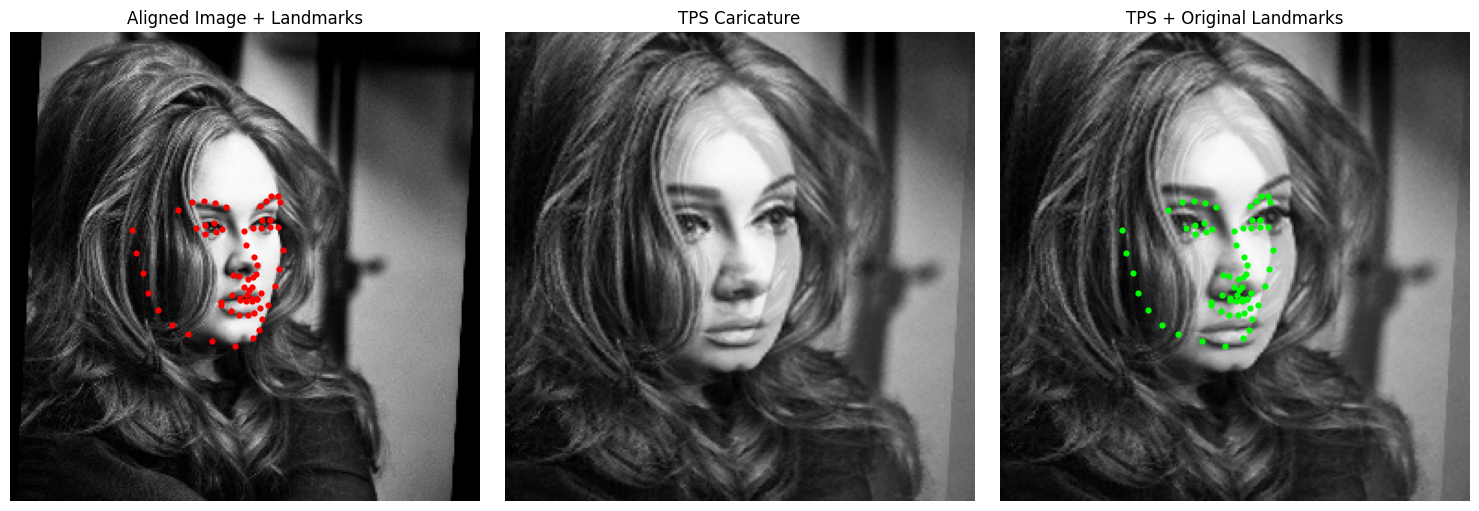

Visualization sample:
Aligned image : C00001_aligned.png
TPS output    : C00001_tps.png
Alpha blend   : 0.75
RBF sigma     : 0.35
Feature weights:
      left_eye: 1.40
     right_eye: 1.40
          nose: 0.90
         mouth: 1.20


In [14]:
# ==================== CELL 10: Simple visualization (LIMITED / SKIP-SAFE) ====================

import matplotlib.pyplot as plt

# Pick first available TPS output
tps_imgs = sorted((DATA_PROCESSED / "tps_rbf").rglob("*_tps.png"))
assert len(tps_imgs) > 0, "No TPS outputs found. Run Cell 8 first."

tps_img_path = tps_imgs[0]
stem = tps_img_path.stem.replace("_tps", "")

aligned_img_path = DATA_ALIGNED / f"{stem}_aligned.png"
aligned_lm_path  = DATA_ALIGNED / f"{stem}_aligned.npy"

assert aligned_img_path.exists(), f"Missing aligned image: {aligned_img_path}"
assert aligned_lm_path.exists(),  f"Missing aligned landmarks: {aligned_lm_path}"

# Load data
aligned_img = np.array(Image.open(aligned_img_path).convert("RGB"))
tps_img     = np.array(Image.open(tps_img_path).convert("RGB"))
pts         = np.load(aligned_lm_path)

# Visualization
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(aligned_img)
ax[0].scatter(pts[:, 0], pts[:, 1], c="red", s=12)
ax[0].set_title("Aligned Image + Landmarks")
ax[0].axis("off")

ax[1].imshow(tps_img)
ax[1].set_title("TPS Caricature")
ax[1].axis("off")

ax[2].imshow(tps_img)
ax[2].scatter(pts[:, 0], pts[:, 1], c="lime", s=12)
ax[2].set_title("TPS + Original Landmarks")
ax[2].axis("off")

plt.tight_layout()
plt.show()

print("=" * 60)
print("Visualization sample:")
print("Aligned image :", aligned_img_path.name)
print("TPS output    :", tps_img_path.name)
print("Alpha blend   :", ALPHA_BLEND)
print("RBF sigma     :", RBF_SIGMA_FACTOR)
print("Feature weights:")
for k, v in FEATURE_WEIGHTS.items():
    print(f"  {k:>12}: {v:.2f}")
print("=" * 60)